# 🧠 Resume Categorization & Intelligent Matching System

This project builds an end-to-end NLP system to:
1. **Classify Resumes**: Predict professional domains using a hybrid Title + Skill weighting logic.
2. **Semantic Matching**: Rank candidates against job descriptions using TF-IDF similarity.
3. **Skill Gap Analysis**: Identify missing keywords to help candidates improve their profiles.

## 1. Project Initialization & Schema Analysis

In [1]:
import ast
import re
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Optional advanced model
try:
    from sentence_transformers import SentenceTransformer
    SBERT_AVAILABLE = True
except Exception:
    SBERT_AVAILABLE = False

# Load Dataset
df = pd.read_csv("resume_data.csv")
df.columns = [col.strip().replace("\ufeff", "") for col in df.columns]

print("--- Dataset Overview ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n--- Columns List ---")
print(df.columns.tolist())
print("\n--- Data Types & Nulls ---")
print(df.info())
print(f"\nSBERT available: {SBERT_AVAILABLE}")

--- Dataset Overview ---
Rows: 9544, Columns: 35

--- Columns List ---
['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', 'job_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score']

--- Data Types & Nulls ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dt

## 2. Target Definition Strategy

Best-practice rule:
- Use the original dataset label (`category`) if available.
- If the label is missing in this dataset version, create a transparent proxy label (`broad_category`) from skill/title heuristics and clearly document this limitation.

In [2]:
def normalize_skills(val):
    if pd.isna(val) or val is None or val == "":
        return []
    if isinstance(val, str) and val.startswith("[") and val.endswith("]"):
        try:
            parsed = ast.literal_eval(val)
            return [str(s).lower().strip() for s in parsed if s]
        except Exception:
            pass
    if isinstance(val, str):
        return [s.lower().strip() for s in re.split(r",|\.|;|\n", val) if s and len(s.strip()) > 1]
    return []


def clean_text(text):
    if pd.isna(text) or text is None or str(text).strip().lower() in {"", "n/a", "none", "nan"}:
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return " ".join(text.split())


def safe_col(name, default=""):
    return df[name] if name in df.columns else default


df["skills_list"] = safe_col("skills", pd.Series([""] * len(df))).apply(normalize_skills)
df["skills_required_list"] = safe_col("skills_required", pd.Series([""] * len(df))).apply(normalize_skills)

CATEGORY_KEYWORDS = {
    "Data Science": ["python", "pandas", "numpy", "tensorflow", "pytorch", "machine learning", "deep learning", "nlp", "ai", "scikit"],
    "Software Engineering": ["java", "c++", "javascript", "react", "node", "docker", "kubernetes", "aws", "devops", "sql"],
    "Engineering": ["mechanical", "civil", "cad", "solidworks", "construction", "manufacturing"],
    "Finance & Accounting": ["accounting", "finance", "audit", "tax", "billing", "bookkeeping"],
    "HR & Management": ["hr", "human resource", "manager", "recruitment", "administrative", "sales"],
}


def map_to_category_advanced(row):
    title = str(row.get("job_position_name", "")).lower()
    skills = row.get("skills_list", [])

    scores = {cat: 0 for cat in CATEGORY_KEYWORDS.keys()}
    for cat, keywords in CATEGORY_KEYWORDS.items():
        for k in keywords:
            if k in title:
                scores[cat] += 3
            if k in skills:
                scores[cat] += 1

    best_cat = max(scores, key=scores.get)
    return best_cat if scores[best_cat] > 0 else "General / Other"


# Preferred target: real label from dataset, fallback: proxy label
if "category" in df.columns:
    df["target_category"] = df["category"].fillna("Unknown").astype(str)
    print("Using original dataset label: category")
else:
    df["target_category"] = df.apply(map_to_category_advanced, axis=1)
    print("`category` not found. Using heuristic proxy: target_category")

print(df["target_category"].value_counts().head(10))

`category` not found. Using heuristic proxy: target_category
target_category
Data Science            4236
Engineering             1330
HR & Management         1159
General / Other         1139
Software Engineering     872
Finance & Accounting     808
Name: count, dtype: int64


## 3. EDA + Text Preprocessing

In [3]:
# Identify source text column for CV content
candidate_resume_cols = [
    "resume", "Resume", "cv", "CV", "career_objective", "responsibilities"
]
resume_col = next((c for c in candidate_resume_cols if c in df.columns), None)
if resume_col is None:
    raise ValueError("No resume-like text column found. Expected one of: resume/career_objective/responsibilities")

# Build cleaned text context
text_cols = [
    "career_objective", "responsibilities", "job_position_name",
    "educationaL_requirements", "experiencere_requirement",
    "responsibilities.1", "skills_required",
]
for col in text_cols:
    if col in df.columns:
        df[f"{col}_cleaned"] = df[col].apply(clean_text)

resume_base = df[resume_col].fillna("").astype(str).apply(clean_text)
skills_text = df["skills_list"].apply(lambda x: " ".join(x) if isinstance(x, list) else "")
resp_text = df["responsibilities_cleaned"] if "responsibilities_cleaned" in df.columns else ""

# Best-practice split of features:
# - classification_text: reduced leakage risk when target is heuristic
# - resume_semantic_context: richer field for similarity matching/ranking
df["classification_text"] = resume_base.str.strip()
df["resume_semantic_context"] = (resume_base + " " + skills_text + " " + resp_text).str.strip()

df = df[df["classification_text"].str.len() > 20].copy()

# EDA features
df["resume_length"] = df["classification_text"].str.len()
print(f"Using resume column: {resume_col}")
print(f"Rows after filtering tiny texts: {len(df)}")

Using resume column: career_objective
Rows after filtering tiny texts: 4740


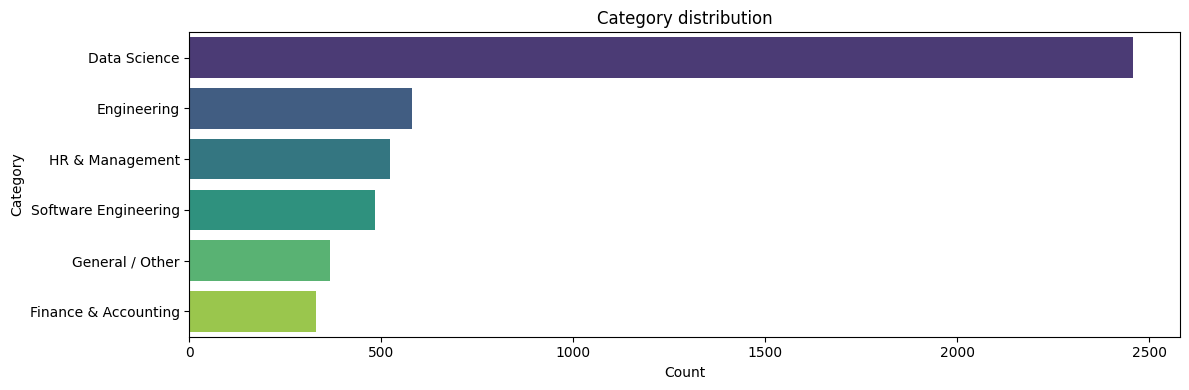

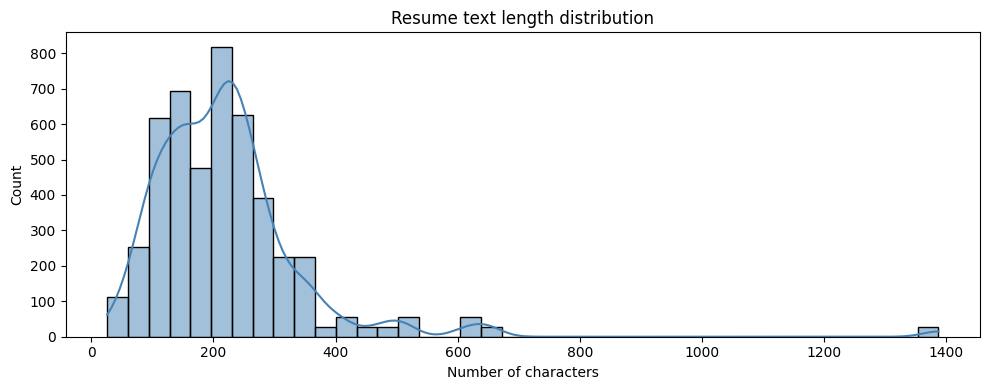

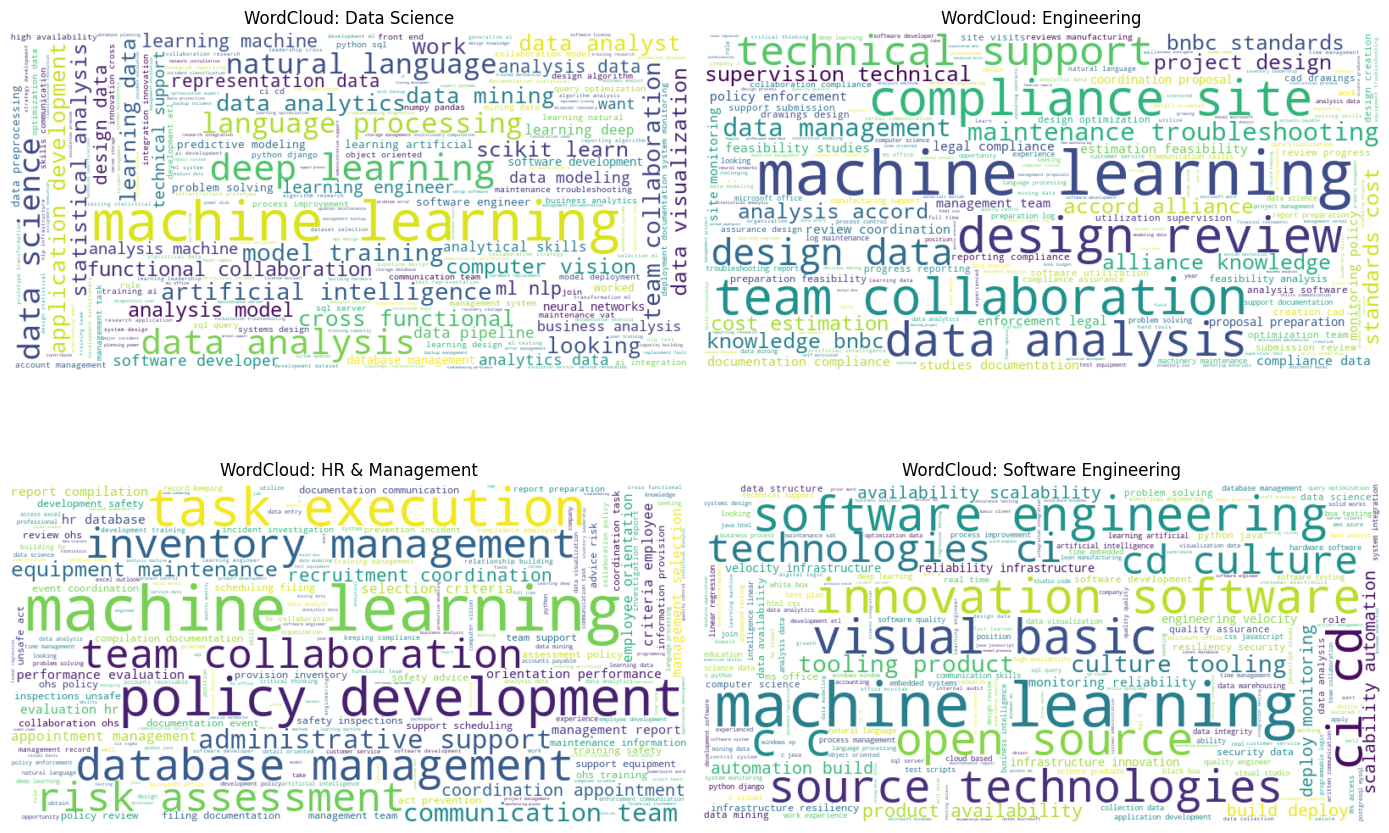

In [4]:
# 3.2 EDA visualizations
plt.figure(figsize=(12, 4))
ax = sns.countplot(
    data=df,
    y="target_category",
    order=df["target_category"].value_counts().index,
    palette="viridis",
)
ax.set_title("Category distribution")
ax.set_xlabel("Count")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(df["resume_length"], bins=40, kde=True, color="steelblue")
plt.title("Resume text length distribution")
plt.xlabel("Number of characters")
plt.tight_layout()
plt.show()

# WordCloud for top categories
top_categories = df["target_category"].value_counts().head(4).index.tolist()
plt.figure(figsize=(14, 10))
for i, cat in enumerate(top_categories, start=1):
    text = " ".join(df.loc[df["target_category"] == cat, "resume_semantic_context"].tolist())
    if not text.strip():
        continue
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.subplot(2, 2, i)
    plt.imshow(wc, interpolation="bilinear")
    plt.title(f"WordCloud: {cat}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Baseline Classification (TF-IDF + Logistic Regression)

--- Tuned Model Metrics (Leakage-Reduced) ---
Best CV Macro F1:  0.5322
Balanced Accuracy: 0.5795
Macro F1:          0.5236

Best params:
{'tfidf__sublinear_tf': False, 'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 5, 'tfidf__max_features': 20000, 'tfidf__max_df': 1.0, 'clf__C': 0.1}

Classification report:

                      precision    recall  f1-score   support

        Data Science       0.76      0.78      0.77       492
         Engineering       0.43      0.20      0.27       116
Finance & Accounting       0.61      0.65      0.63        66
     General / Other       0.47      1.00      0.64        73
     HR & Management       0.28      0.12      0.17       104
Software Engineering       0.61      0.72      0.66        97

            accuracy                           0.64       948
           macro avg       0.53      0.58      0.52       948
        weighted avg       0.62      0.64      0.61       948



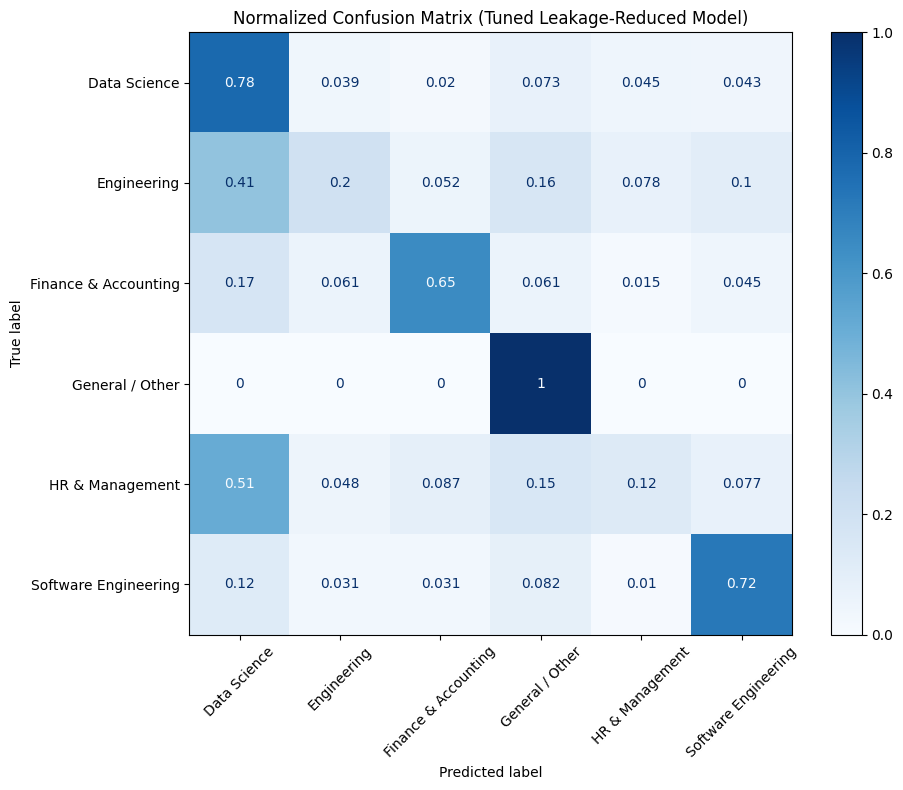

In [5]:
X = df["classification_text"]
y = df["target_category"].astype(str)

# Keep only classes with enough samples for stable CV and holdout split
min_class_samples = 20
valid_classes = y.value_counts()[y.value_counts() >= min_class_samples].index
df_model = df[df["target_category"].isin(valid_classes)].copy()
X = df_model["classification_text"]
y = df_model["target_category"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Final holdout set (never seen during tuning)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded,
)

base_pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english")),
        (
            "clf",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=SEED,
                solver="saga",
                n_jobs=-1,
            ),
        ),
    ]
)

param_distributions = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__max_features": [5000, 10000, 20000, None],
    "tfidf__min_df": [1, 2, 3, 5],
    "tfidf__max_df": [0.85, 0.9, 0.95, 1.0],
    "tfidf__sublinear_tf": [True, False],
    "clf__C": [0.1, 0.3, 1.0, 3.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
search = RandomizedSearchCV(
    estimator=base_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)

search.fit(X_train, y_train)
pipeline = search.best_estimator_
y_pred = pipeline.predict(X_test)

print("--- Tuned Model Metrics (Leakage-Reduced) ---")
print(f"Best CV Macro F1:  {search.best_score_:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1:          {f1_score(y_test, y_pred, average='macro'):.4f}")
print("\nBest params:")
print(search.best_params_)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=le.classes_,
    normalize="true",
    cmap="Blues",
    xticks_rotation=45,
    ax=ax,
)
ax.set_title("Normalized Confusion Matrix (Tuned Leakage-Reduced Model)")
plt.tight_layout()
plt.show()

## 5. Intelligent Matching (TF-IDF baseline + optional SBERT)

Validation note:
- Classification is tuned with stratified CV and evaluated on a final holdout split.
- When target labels are heuristic, report these results as proxy performance (not fully independent ground truth).

In [6]:
# Fit a standalone TF-IDF vectorizer for matching and explainability
match_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=12000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    stop_words="english",
)
match_vectorizer.fit(df_model["resume_semantic_context"])


def extract_keywords(text, top_k=20):
    cleaned = clean_text(text)
    if not cleaned:
        return []
    vec = match_vectorizer.transform([cleaned])
    scores = vec.toarray().ravel()
    if scores.sum() == 0:
        return []
    top_idx = np.argsort(scores)[::-1][:top_k]
    features = np.array(match_vectorizer.get_feature_names_out())
    return [features[i] for i in top_idx if scores[i] > 0]


def calculate_match_score_tfidf(resume_text, job_desc):
    vecs = match_vectorizer.transform([clean_text(resume_text), clean_text(job_desc)])
    return float(cosine_similarity(vecs[0], vecs[1])[0][0])


_SBERT_MODEL = None


def get_sbert_model():
    global _SBERT_MODEL
    if not SBERT_AVAILABLE:
        return None
    if _SBERT_MODEL is None:
        _SBERT_MODEL = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    return _SBERT_MODEL


def calculate_match_score_sbert(resume_text, job_desc):
    sbert = get_sbert_model()
    if sbert is None:
        return None
    emb = sbert.encode([resume_text, job_desc], normalize_embeddings=True)
    return float(np.dot(emb[0], emb[1]))


def analyze_candidate(resume_text, job_requirements_text):
    cleaned = clean_text(resume_text)
    pred_encoded = pipeline.predict([cleaned])[0]
    domain = le.classes_[pred_encoded]

    tfidf_score = calculate_match_score_tfidf(resume_text, job_requirements_text)
    sbert_score = calculate_match_score_sbert(resume_text, job_requirements_text)

    resume_kw = set(extract_keywords(resume_text, top_k=25))
    job_kw = set(extract_keywords(job_requirements_text, top_k=25))
    common_kw = sorted(resume_kw & job_kw)
    missing_kw = sorted(job_kw - resume_kw)

    return {
        "Predicted Domain": domain,
        "TF-IDF Match": f"{tfidf_score:.2%}",
        "SBERT Match": f"{sbert_score:.2%}" if sbert_score is not None else "Not available (install sentence-transformers)",
        "Matched Keywords": common_kw[:12] if common_kw else "None",
        "Missing Keywords": missing_kw[:12] if missing_kw else "None",
    }


def rank_candidates_for_job(job_text, candidate_texts, top_k=5, method="tfidf"):
    sbert = get_sbert_model() if method == "sbert" else None
    if method == "sbert" and sbert is not None:
        cand_emb = sbert.encode(candidate_texts, normalize_embeddings=True)
        job_emb = sbert.encode([job_text], normalize_embeddings=True)[0]
        scores = np.dot(cand_emb, job_emb)
    else:
        job_vec = match_vectorizer.transform([clean_text(job_text)])
        cand_vec = match_vectorizer.transform([clean_text(t) for t in candidate_texts])
        scores = cosine_similarity(cand_vec, job_vec).ravel()

    ranking = pd.DataFrame(
        {
            "candidate_text": candidate_texts,
            "score": scores,
        }
    ).sort_values("score", ascending=False)
    return ranking.head(top_k)


# Final demo
demo_resume = "Experienced software engineer proficient in Python and React. Deep knowledge of AWS and Docker."
demo_job = "Senior developer for cloud infrastructure with Python, Docker, AWS and Kubernetes."

result = analyze_candidate(demo_resume, demo_job)
print("--- Candidate Analysis ---")
for k, v in result.items():
    print(f"{k}: {v}")

sample_candidates = df_model["resume_semantic_context"].sample(20, random_state=SEED).tolist()
print("\n--- Top candidates for demo job ---")
display(rank_candidates_for_job(demo_job, sample_candidates, top_k=5, method="tfidf"))

--- Candidate Analysis ---
Predicted Domain: Data Science
TF-IDF Match: 14.79%
SBERT Match: Not available (install sentence-transformers)
Matched Keywords: ['aws', 'docker', 'python']
Missing Keywords: ['aws kubernetes', 'cloud', 'cloud infrastructure', 'developer', 'infrastructure', 'infrastructure python', 'kubernetes', 'senior']

--- Top candidates for demo job ---


,candidate_text,score
1,i want to join a role where i can experiment a...,0.076146
7,machine learning engineer seeking roles in mac...,0.061085
8,i am a fresher who is looking to work as a sof...,0.055241
3,looking to utilize hands on experience of mach...,0.039163
19,i am currently working as a junior machine lea...,0.033550
